
# Analisis Keterhubungan dan Jalur Terpendek pada Jaringan GitHub Menggunakan Algoritma Breadth-First Search (BFS)




##Flowchart
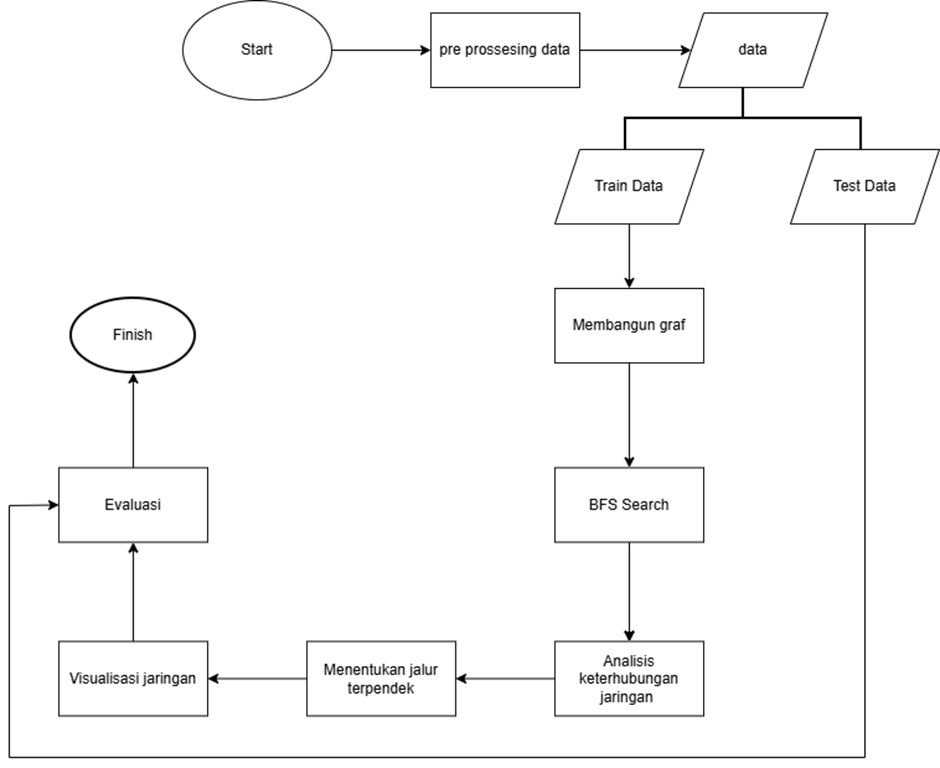

In [ ]:
from collections import deque
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import networkx as nx
import matplotlib.pyplot as plt


## 1. Memuat Data




In [ ]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')
# Load data edge list
edges_path = "/content/drive/MyDrive/JST/musae_git_edges.csv"
df_edges = pd.read_csv(edges_path)

print("Jumlah edge:", len(df_edges))
df_edges.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah edge: 289003


,id_1,id_2
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982


## 2. Pra-pemprosesan Data



In [ ]:

# Pastikan nama kolom sesuai
expected_cols = {'id_1', 'id_2'}
if not expected_cols.issubset(df_edges.columns):
    raise ValueError(f"Kolom dataset harus memuat {expected_cols}, tetapi yang ditemukan: {list(df_edges.columns)}")

# Ambil hanya kolom yang diperlukan
edges_clean = df_edges[['id_1', 'id_2']].copy()

# Hapus baris kosong
edges_clean = edges_clean.dropna()

# Ubah tipe data ke integer
edges_clean['id_1'] = edges_clean['id_1'].astype(int)
edges_clean['id_2'] = edges_clean['id_2'].astype(int)

# Hapus self-loop (node terhubung ke dirinya sendiri)
edges_clean = edges_clean[edges_clean['id_1'] != edges_clean['id_2']]

# Untuk graf tak berarah, pasangan (u, v) dan (v, u) dianggap sama
edges_clean[['u', 'v']] = pd.DataFrame(
    edges_clean.apply(lambda row: sorted((row['id_1'], row['id_2'])), axis=1).tolist(),
    index=edges_clean.index
)
edges_clean = edges_clean[['u', 'v']].drop_duplicates().reset_index(drop=True)

print(f"Jumlah edge setelah cleaning: {len(edges_clean):,}")
print(f"Jumlah node unik: {pd.unique(edges_clean[['u', 'v']].values.ravel()).size:,}")
edges_clean.head()


Jumlah edge setelah cleaning: 289,003
Jumlah node unik: 37,700


,u,v
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982


##3. Split Train & Test data

In [ ]:
train_edges, test_edges = train_test_split(
    edges_clean,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_edges = train_edges.reset_index(drop=True)
test_edges = test_edges.reset_index(drop=True)

print("Jumlah train edges:", len(train_edges))
print("Jumlah test edges :", len(test_edges))
print(f"Proporsi train     : {len(train_edges)/len(edges_clean):.2%}")
print(f"Proporsi test      : {len(test_edges)/len(edges_clean):.2%}")

Jumlah train edges: 231202
Jumlah test edges : 57801
Proporsi train     : 80.00%
Proporsi test      : 20.00%


## 4. Membangun Graf

Graf dibentuk sebagai adjacency list  untuk implementasi BFS.

In [ ]:
def build_graph_from_edges(df, col_u="u", col_v="v", undirected=True):
    graph = {}

    for u, v in zip(df[col_u], df[col_v]):
        graph.setdefault(u, set()).add(v)
        graph.setdefault(v, set())
        if undirected:
            graph[v].add(u)

    # Ubah set menjadi list terurut agar hasil BFS konsisten
    return {node: sorted(neighbors) for node, neighbors in graph.items()}


graph = build_graph_from_edges(train_edges)

num_nodes = len(graph)
num_edges = len(train_edges)

print("Jumlah node pada graph train:", num_nodes)
print("Jumlah edge pada graph train:", num_edges)

Jumlah node pada graph train: 36511
Jumlah edge pada graph train: 231202


## 5. Implementasi Algoritma Breadth-First Search (BFS)

In [ ]:
def bfs_shortest_path(graph, start_node, target_node=None):
    """
    BFS untuk:
    1) mengecek keterjangkauan node,
    2) mencari jalur terpendek pada graf tak berbobot,
    3) menghitung jarak dari start_node ke node lain.
    """
    if start_node not in graph:
        raise ValueError(f"Node {start_node} tidak ada di graph.")

    queue = deque([start_node])
    visited = {start_node}
    parent = {start_node: None}
    distance = {start_node: 0}
    visit_order = []

    while queue:
        current = queue.popleft()
        visit_order.append(current)

        if target_node is not None and current == target_node:
            break

        for neighbor in graph[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                distance[neighbor] = distance[current] + 1
                queue.append(neighbor)

    # Jika target ditentukan tetapi tidak ditemukan
    if target_node is not None and target_node not in visited:
        return {
            "found": False,
            "path": None,
            "distance": None,
            "visited_count": len(visited),
            "visit_order": visit_order,
            "reachable_nodes": visited
        }

    # Rekonstruksi jalur jika target ditemukan
    path = None
    if target_node is not None:
        path = []
        node = target_node
        while node is not None:
            path.append(node)
            node = parent[node]
        path.reverse()

    return {
        "found": True,
        "path": path,
        "distance": distance.get(target_node) if target_node is not None else distance,
        "visited_count": len(visited),
        "visit_order": visit_order,
        "reachable_nodes": visited
    }

## 6. Analisis Keterhubungan Jaringan

Untuk melihat apakah graf terhubung secara global atau terbagi menjadi beberapa komponen terhubung.

In [ ]:
def connected_components_bfs(graph):
    """Mengembalikan daftar komponen terhubung menggunakan BFS."""
    unvisited = set(graph.keys())
    components = []

    while unvisited:
        start = next(iter(unvisited))
        result = bfs_shortest_path(graph, start)
        component = sorted(result["reachable_nodes"])
        components.append(component)
        unvisited -= set(component)

    return components


components = connected_components_bfs(graph)
component_sizes = sorted([len(c) for c in components], reverse=True)

print(f"Jumlah komponen terhubung: {len(components):,}")
print(f"Ukuran 5 komponen terbesar: {component_sizes[:5]}")
print("Apakah graph terhubung secara global?", "Ya" if len(components) == 1 else "Tidak")

Jumlah komponen terhubung: 45
Ukuran 5 komponen terbesar: [36417, 3, 3, 3, 3]
Apakah graph terhubung secara global? Tidak


## 7. Analisis Jalur Terpendek Antar Simpul



In [ ]:

# Contoh pasangan node
train_nodes = sorted(graph.keys())
start_node = train_nodes[0]
target_node = train_nodes[1]

result_path = bfs_shortest_path(graph, start_node, target_node)

print(f"Start node : {start_node}")
print(f"Target node: {target_node}")
print(f"Path ditemukan: {result_path['found']}")
print(f"Jalur terpendek: {result_path['path']}")
print(f"Panjang jalur (jumlah edge): {result_path['distance']}")
print(f"Jumlah node yang dikunjungi: {result_path['visited_count']}")


Start node : 1
Target node: 3
Path ditemukan: True
Jalur terpendek: [1, 2370, 27803, 5916, 3]
Panjang jalur (jumlah edge): 4
Jumlah node yang dikunjungi: 35645


## 8. Hasil Penelitian

In [ ]:
def summarize_graph(graph, edges_df, components):
    num_nodes = len(graph)
    num_edges = len(edges_df)
    num_components = len(components)
    largest_component = max(len(c) for c in components) if components else 0

    summary = {
        "jumlah_node_train": num_nodes,
        "jumlah_edge_train": num_edges,
        "jumlah_komponen_terhubung": num_components,
        "ukuran_komponen_terbesar": largest_component,
        "graph_terhubung_global": num_components == 1
    }
    return pd.DataFrame([summary])

summary_df = summarize_graph(graph, train_edges, components)
display(summary_df)

,jumlah_node_train,jumlah_edge_train,jumlah_komponen_terhubung,ukuran_komponen_terbesar,graph_terhubung_global
0,36511,231202,45,36417,False


## 9. Evaluasi pada data test

In [ ]:
def evaluate_test_edges(graph, test_edges_df, max_samples=None):
    rows = []
    data_iter = test_edges_df if max_samples is None else test_edges_df.head(max_samples)

    for _, row in data_iter.iterrows():
        u, v = row["u"], row["v"]

        u_in_graph = u in graph
        v_in_graph = v in graph

        if u_in_graph and v_in_graph:
            bfs_result = bfs_shortest_path(graph, u, v)
            connected = bfs_result["found"]
            dist = bfs_result["distance"] if connected else None
        else:
            connected = False
            dist = None

        rows.append({
            "u": u,
            "v": v,
            "u_di_graph_train": u_in_graph,
            "v_di_graph_train": v_in_graph,
            "terhubung_di_graph_train": connected,
            "jarak_bfs_di_train": dist
        })

    return pd.DataFrame(rows)

test_eval_df = evaluate_test_edges(graph, test_edges, max_samples=1000)

display(test_eval_df.head())

coverage_both_nodes = (test_eval_df["u_di_graph_train"] & test_eval_df["v_di_graph_train"]).mean()
connectivity_rate = test_eval_df["terhubung_di_graph_train"].mean()

print(f"Proporsi pasangan test dengan kedua node muncul di graph train : {coverage_both_nodes:.2%}")
print(f"Proporsi pasangan test yang tetap terhubung di graph train     : {connectivity_rate:.2%}")

,u,v,u_di_graph_train,v_di_graph_train,terhubung_di_graph_train,jarak_bfs_di_train
0,14321,19255,True,True,True,3.0
1,11798,31010,True,False,False,NaN
2,4,2865,True,True,True,5.0
3,7321,26034,True,True,True,2.0
4,654,21375,True,True,True,3.0


Proporsi pasangan test dengan kedua node muncul di graph train : 97.50%
Proporsi pasangan test yang tetap terhubung di graph train     : 97.50%


## 10. Visualisasi

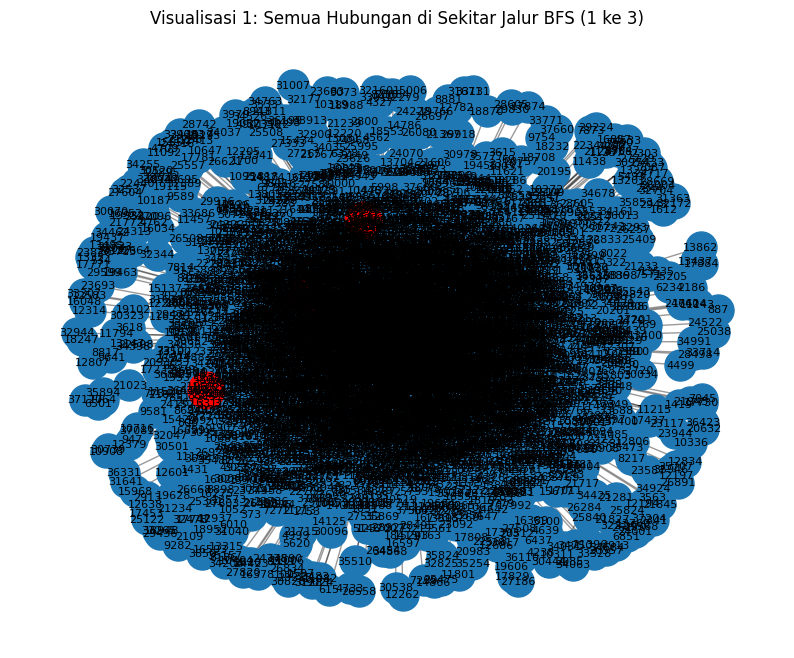

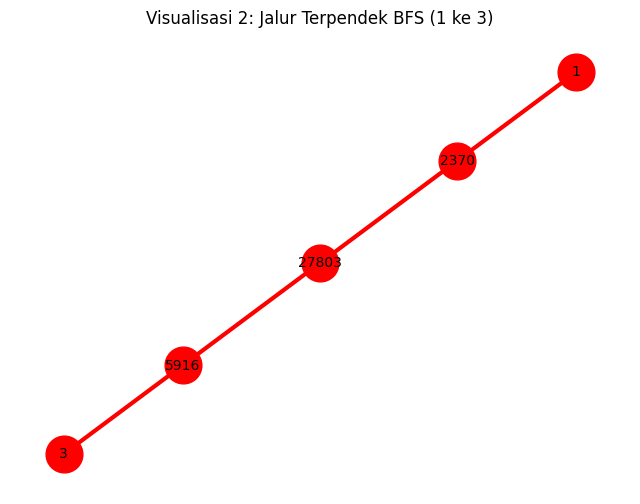

In [ ]:
G = nx.Graph(graph)

if result_path["found"] and result_path["path"] is not None:
    path_nodes = result_path["path"]
    path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))

    # Visualisasi 1: lingkungan sekitar jalur
    neighborhood_nodes = set(path_nodes)
    for node in path_nodes:
        if node in G:
            neighborhood_nodes.update(G.neighbors(node))

    sub_path_G = G.subgraph(neighborhood_nodes)

    plt.figure(figsize=(10, 8))
    pos1 = nx.spring_layout(sub_path_G, seed=42)

    nx.draw_networkx_edges(sub_path_G, pos1, alpha=0.4)
    nx.draw_networkx_nodes(sub_path_G, pos1, node_size=500)
    nx.draw_networkx_labels(sub_path_G, pos1, font_size=8)

    nx.draw_networkx_edges(
        sub_path_G,
        pos1,
        edgelist=path_edges,
        width=3,
        edge_color="red"
    )

    nx.draw_networkx_nodes(
        sub_path_G,
        pos1,
        nodelist=path_nodes,
        node_size=700,
        node_color="red"
    )

    plt.title(f"Visualisasi 1: Semua Hubungan di Sekitar Jalur BFS ({start_node} ke {target_node})")
    plt.axis("off")
    plt.show()

    # Visualisasi 2: jalur terpendek saja
    path_graph = G.edge_subgraph(path_edges).copy()

    plt.figure(figsize=(8, 6))
    pos2 = nx.spring_layout(path_graph, seed=42)

    nx.draw_networkx_edges(
        path_graph,
        pos2,
        edgelist=path_edges,
        width=3,
        edge_color="red"
    )

    nx.draw_networkx_nodes(
        path_graph,
        pos2,
        nodelist=path_nodes,
        node_size=700,
        node_color="red"
    )

    nx.draw_networkx_labels(path_graph, pos2, font_size=10)

    plt.title(f"Visualisasi 2: Jalur Terpendek BFS ({start_node} ke {target_node})")
    plt.axis("off")
    plt.show()

else:
    print("Jalur tidak ditemukan sehingga tidak dapat divisualisasikan.")